# Clasificación de variedades de trigo
https://www.kaggle.com/datasets/sudhanshu2198/wheat-variety-classification
## Información del conjunto de datos
El conjunto de datos comprende granos de trigo pertenecientes a tres variedades diferentes: Kama, Rosa y Canadian, con 70 elementos cada una. Todos estos parámetros fueron de valor real continuo.
## Información de las variables
Para construir los datos, se midieron siete variables geométricas de los granos de trigo: área A, perímetro P, compactibilidad $C = 4pi*A/P^2$, longitud del grano, ancho del grano, coeficiente de asimetría y longitud del surco del grano.

 ## 🎯 Objetivo
Diferenciar entre variedades de trigo.

## Carga de librerías y datos

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches
import plotly.express as px
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import MDS, Isomap, TSNE

In [66]:
!gdown 1J8I0tGdrTHXjGFM51pxMvO_kBJoIeOm1

Downloading...
From: https://drive.google.com/uc?id=1J8I0tGdrTHXjGFM51pxMvO_kBJoIeOm1
To: /content/wheat.csv
100% 10.0k/10.0k [00:00<00:00, 24.5MB/s]


In [67]:
df = pd.read_csv("wheat.csv")

## Estructura

In [68]:
df.head()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length,category
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1.0
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1.0
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1.0
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1.0
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1.0


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   area                   210 non-null    float64
 1   perimeter              210 non-null    float64
 2   compactness            210 non-null    float64
 3   length                 210 non-null    float64
 4   width                  210 non-null    float64
 5   asymmetry coefficient  210 non-null    float64
 6   groove length          210 non-null    float64
 7   category               210 non-null    float64
dtypes: float64(8)
memory usage: 13.3 KB


In [70]:
df.describe()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length,category
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071,2.000000
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480,0.818448
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000,1.000000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000,1.000000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000,2.000000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000,3.000000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000,3.000000


In [71]:
target_names = {
    1:'Kama',
    2:'Rosa',
    3:'Canadian'
}

df['category'] = df['category'].astype('category').map(target_names)

In [72]:
df.head()

,area,perimeter,compactness,length,width,asymmetry coefficient,groove length,category
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama


El proceso inverso se puede realizar con la función [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html#sklearn.preprocessing.LabelEncoder)

In [73]:
df["category"].value_counts()

,count
category,
Kama,70
Rosa,70
Canadian,70


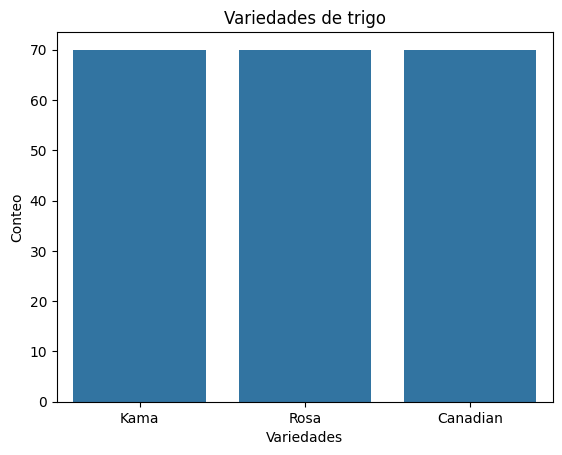

In [74]:
sns.countplot( x="category", data=df)
plt.title('Variedades de trigo')
plt.xlabel('Variedades')
plt.ylabel('Conteo')
plt.show()

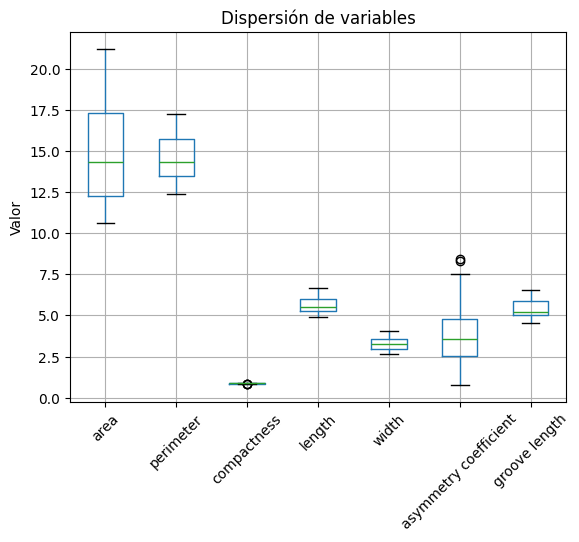

In [75]:
df.boxplot(rot=45)
plt.title('Dispersión de variables')
plt.ylabel('Valor')
plt.show()

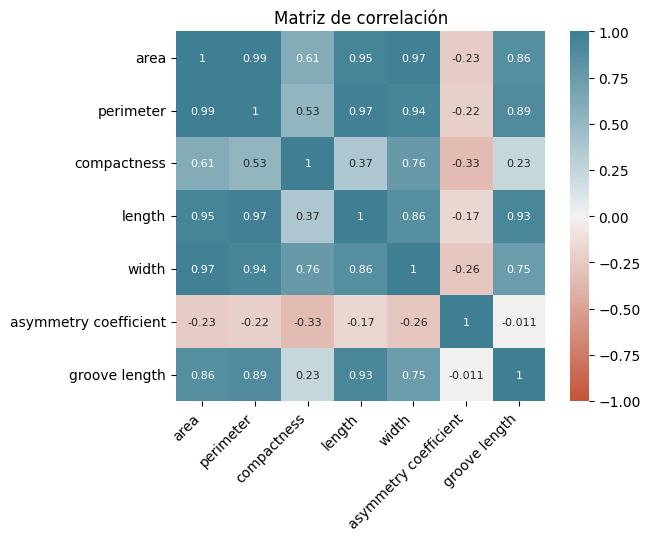

In [76]:
corr = df.drop(['category'], axis=1).corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 8}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.title('Matriz de correlación')
plt.show()

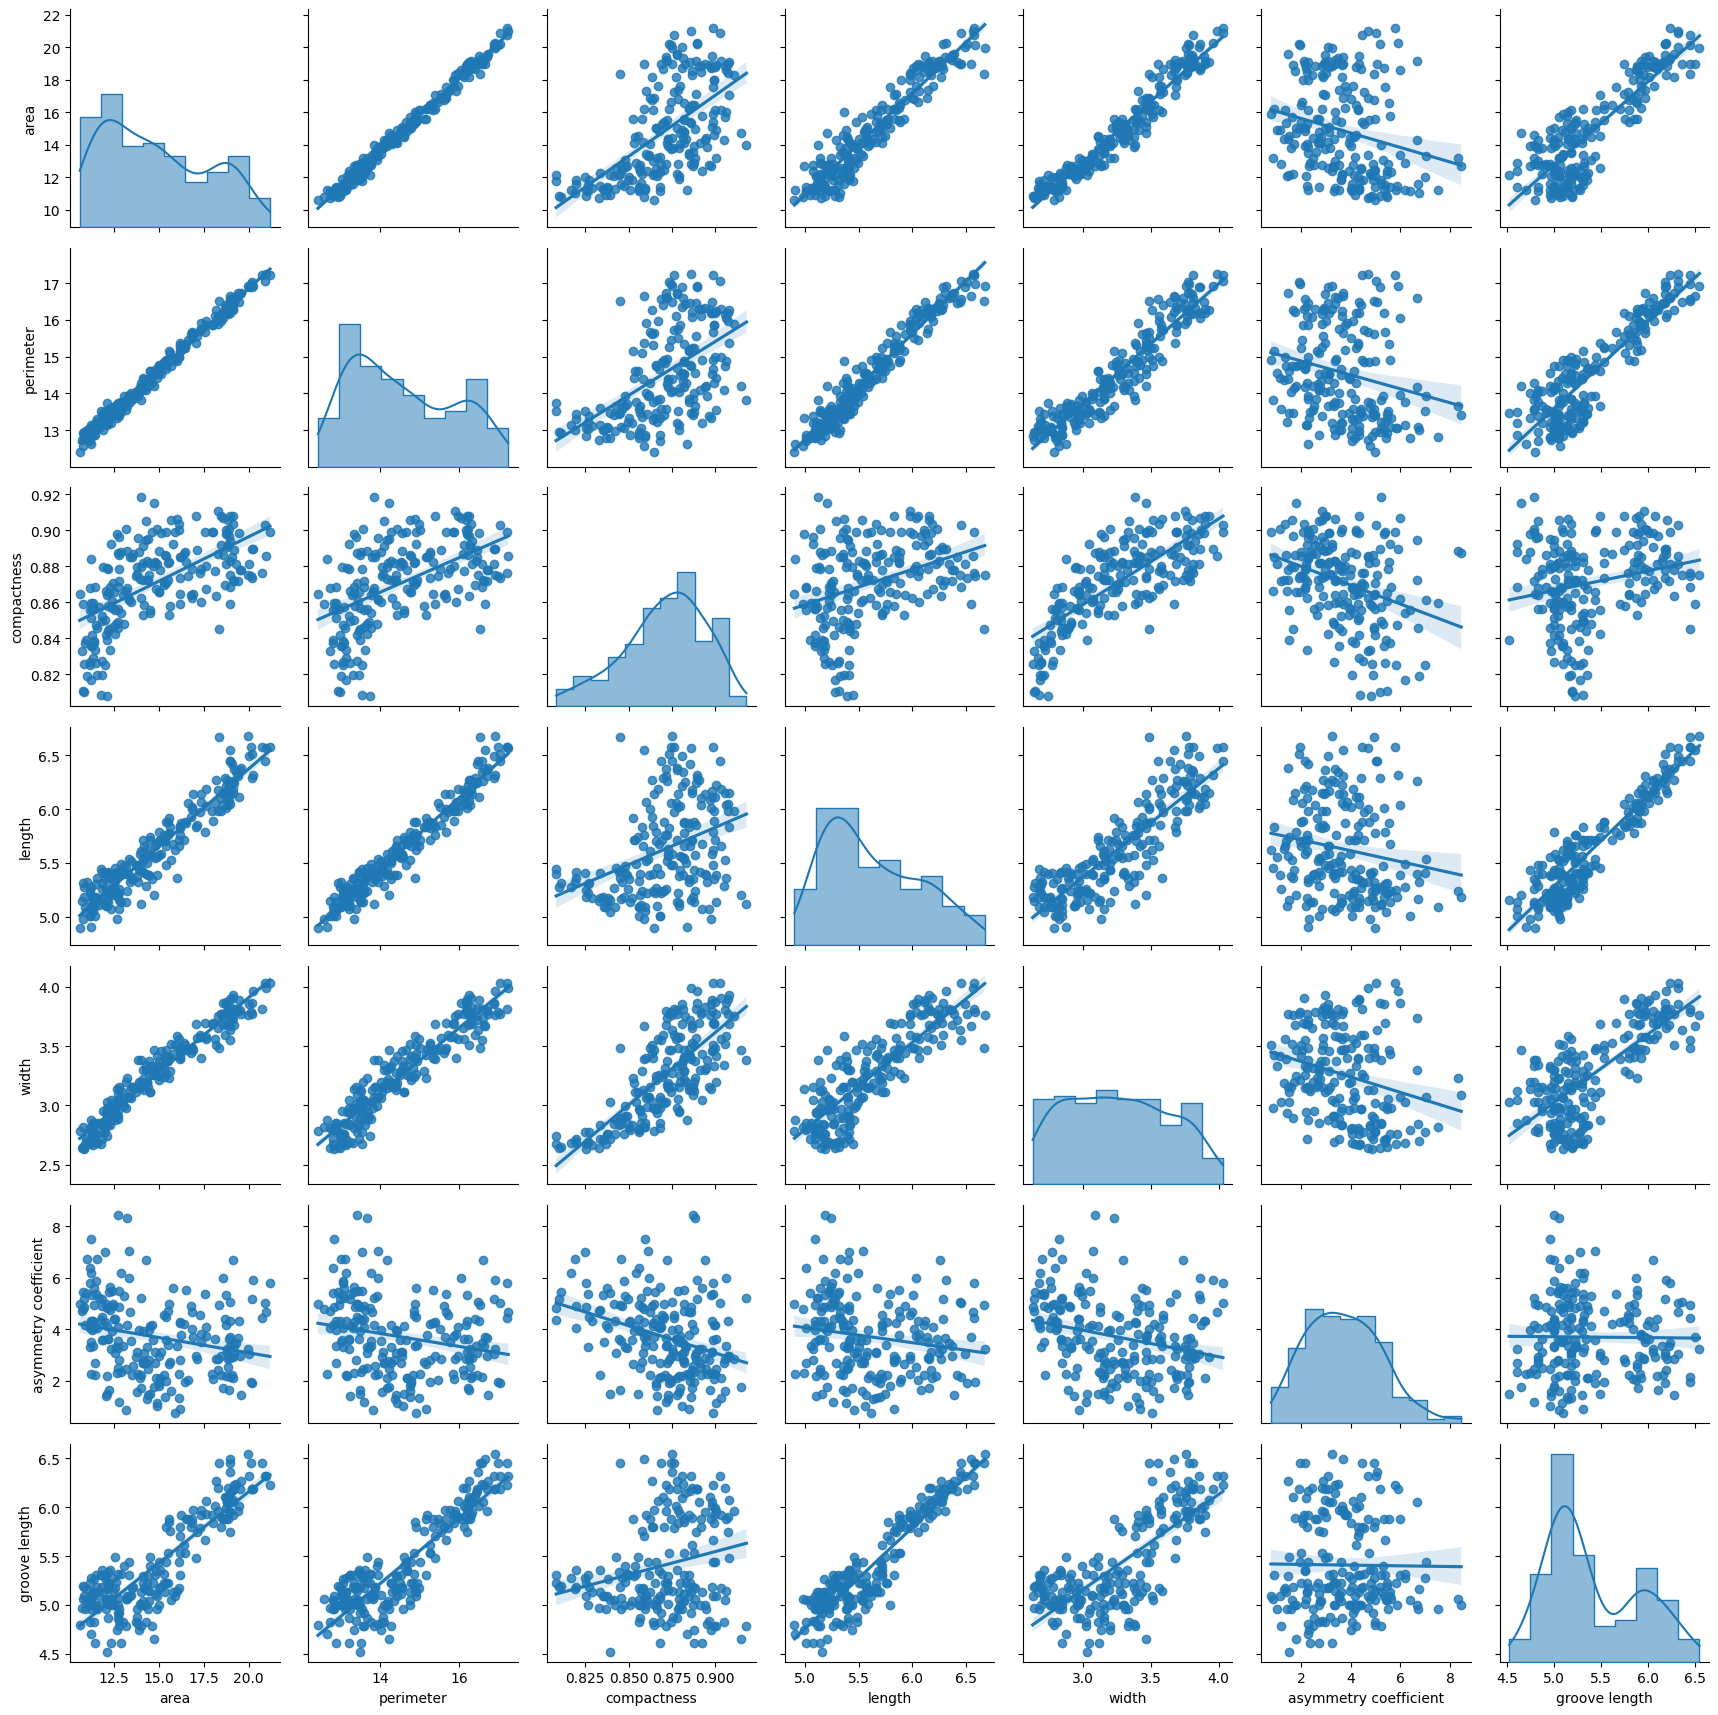

In [77]:
g = sns.PairGrid(df)
g.map_diag(sns.histplot, kde=True, element='step')
g.map_offdiag(sns.regplot)

## Estandarización o Z-score
[Documentación de StandardScaler en sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler)

In [78]:
df_x = df.drop(['category'], axis=1)
df_y = df['category']
#df_std = (df_x-df_x.mean())/df_x.std()
scaler = StandardScaler().set_output(transform="pandas")
df_std = scaler.fit_transform(df_x)
df_std.shape

(210, 7)

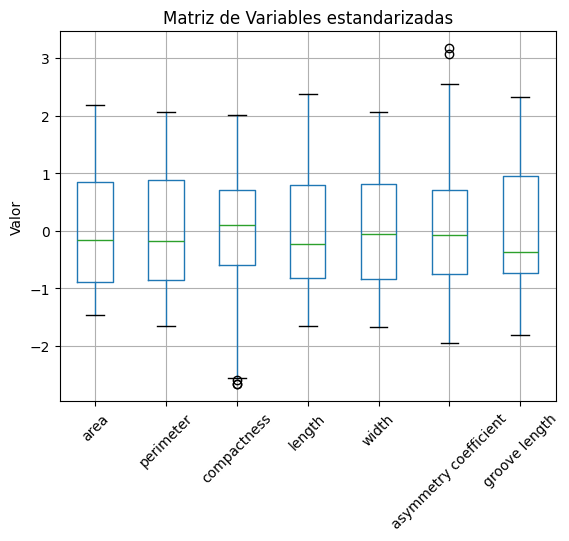

In [79]:
df_std.boxplot(rot=45)
plt.title('Matriz de Variables estandarizadas')
plt.ylabel('Valor')
plt.show()

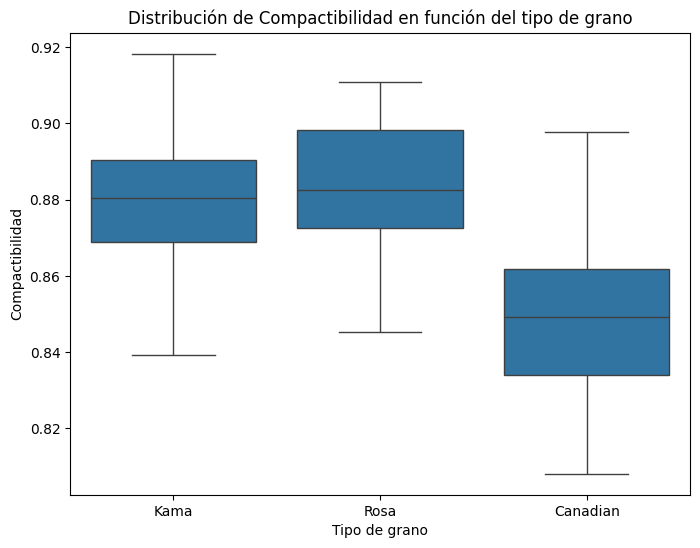

In [80]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='category', y='compactness', data=df)
plt.title('Distribución de Compactibilidad en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.ylabel('Compactibilidad')
plt.show()

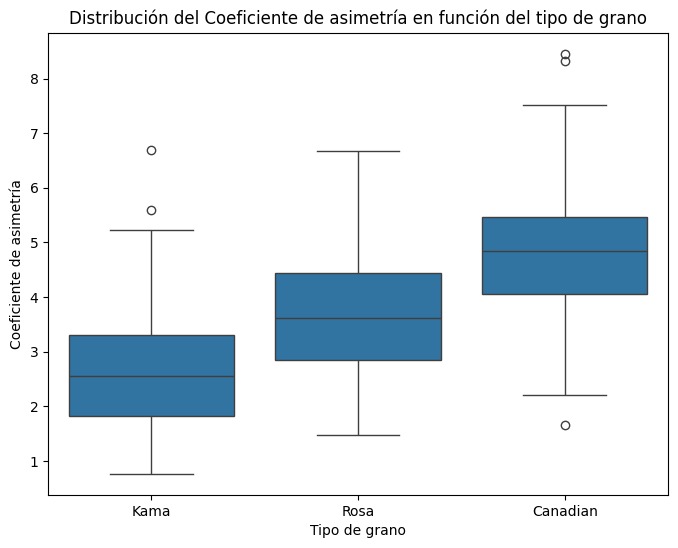

In [81]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='category', y='asymmetry coefficient', data=df)
plt.title('Distribución del Coeficiente de asimetría en función del tipo de grano')
plt.xlabel('Tipo de grano')
plt.ylabel('Coeficiente de asimetría')
plt.show()

## Outliers

In [82]:
# IQR
# Columnas con outliers
outliers_col = ["asymmetry coefficient"]
# limite mayor y menor
for col in outliers_col:
    Q1 = df_x[col].quantile(0.25)
    Q3 = df_x[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    # Arreglo de booleanos que indican las filas con outliers
    upper_array = np.where(df_x[col] >= upper)[0]
    lower_array = np.where(df_x[col] <= lower)[0]

    # Reemoción de outliers
    df_x.drop(index=upper_array, inplace=True)
    df_x.drop(index=lower_array, inplace=True)
    df_y.drop(index=upper_array, inplace=True)
    df_y.drop(index=lower_array, inplace=True)

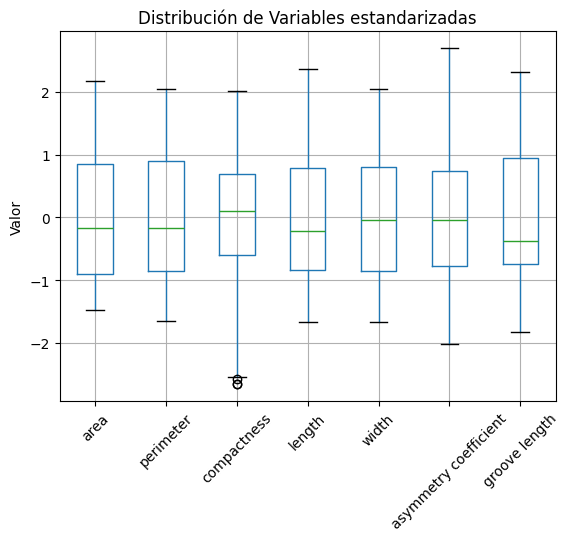

In [83]:
df_std = scaler.fit_transform(df_x)
df_std.boxplot(rot=45)
plt.title('Distribución de Variables estandarizadas')
plt.ylabel('Valor')
plt.show()

## PCA
[Guía de usuario sklearn: PCA](https://scikit-learn.org/stable/modules/decomposition.html#principal-component-analysis-pca)

### Aplicación de la técnica

[Documentación PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)

In [84]:
# Obtener todas las componentes principales
pca = PCA(n_components=df_std.shape[1]).set_output(transform="pandas")

pca_df = pca.fit_transform(df_std)

pca_df['target'] = df_y

En la siguiente tabla vemos la proyección de cada variedad en cada una de los nuevos atributos.

In [85]:
pca_df

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,target
0,0.302993,-0.803914,-0.629319,-0.416692,0.103964,0.021854,-0.014179,Kama
1,-0.012959,-1.958981,-0.685141,-0.432771,-0.049181,0.018472,-0.004458,Kama
2,-0.466078,-1.906960,0.951252,-0.111781,0.011442,-0.050562,-0.004875,Kama
3,-0.599193,-1.943015,0.510488,-0.228773,-0.072318,0.229329,-0.010824,Kama
4,1.093284,-2.102197,0.040586,-0.142655,-0.020196,0.052395,-0.000378,Kama
...,...,...,...,...,...,...,...,...
204,-2.017580,-0.068016,0.000972,-0.059248,-0.149158,-0.009548,-0.007706,Canadian
205,-1.999313,-0.850522,0.554982,0.149569,0.086750,-0.024536,0.019301,Canadian
206,-2.738744,0.233562,-0.002936,0.174673,0.034112,0.053976,0.033499,Canadian
208,-2.351136,-0.091792,-0.341133,0.142848,-0.058325,-0.050796,0.014130,Canadian


### Eigenvectors
Son los ejes principales del espacio de características, representan las direcciones de máxima varianza en los datos y son ortogonales entre si. Sobre ellos se proyectan los datos estandarizados.

In [86]:
pd.DataFrame(pca.components_,
             columns=['pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6'],
             index=df_x.columns)

,pca0,pca1,pca2,pca3,pca4,pca5,pca6
area,0.444185,0.441198,0.281056,0.423045,0.433135,-0.115284,0.386248
perimeter,0.027699,0.084889,-0.526559,0.205778,-0.115273,0.720909,0.373391
compactness,0.026196,-0.060966,0.629151,-0.217890,0.215852,0.676288,-0.219845
length,-0.193701,-0.295691,0.331978,-0.264564,-0.198358,-0.088299,0.804799
width,-0.205917,-0.178323,0.334727,0.765475,-0.462529,0.038579,-0.111282
asymmetry coefficient,-0.423251,-0.477049,-0.142530,0.270654,0.705393,-0.018142,0.042492
groove length,0.736331,-0.669039,-0.073110,0.044857,-0.040688,-0.004502,-0.034208


### Selección del número de componentes principales

In [87]:
# Creamos función para acumular la varianza
def acumular(numbers):
     sum = 0
     var_c = []
     for num in numbers:
        sum += num
        var_c.append(sum)
     return var_c

In [88]:
var_c = acumular(pca.explained_variance_ratio_)
pca_rtd = pd.DataFrame({'Eigenvalues':pca.explained_variance_,
                        'Proporción de variancia explicada':pca.explained_variance_ratio_,
                        'Proporción acumulado de variancia explicada': var_c})
pca_rtd

,Eigenvalues,Proporción de variancia explicada,Proporción acumulado de variancia explicada
0,5.061600,0.719609,0.719609
1,1.250601,0.177798,0.897408
2,0.627599,0.089226,0.986634
3,0.069121,0.009827,0.996461
4,0.018751,0.002666,0.999126
5,0.005331,0.000758,0.999884
6,0.000813,0.000116,1.000000


Vemos gráficamente la varianza acumulada:

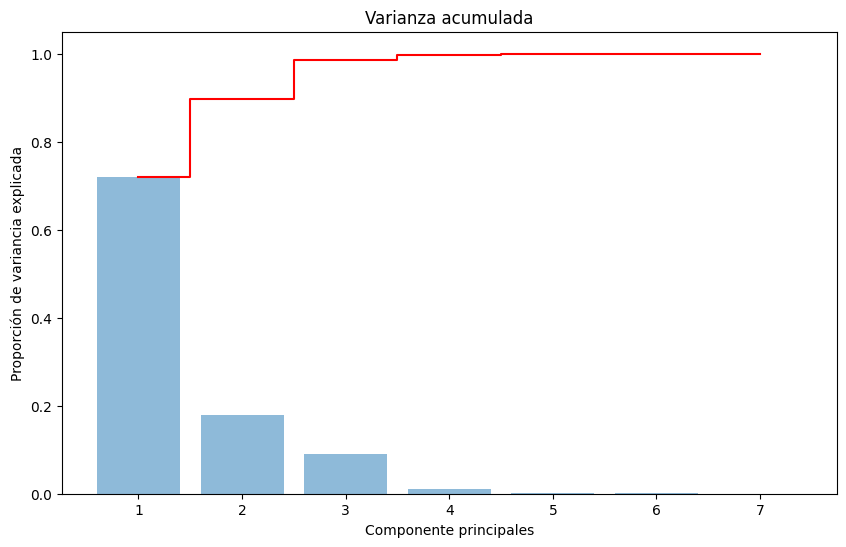

In [89]:
n_components = np.arange(pca.n_components) + 1
plt.figure(figsize=(10, 6))
plt.bar(range(1,pca.n_components + 1), pca.explained_variance_ratio_,
        alpha=0.5,
        align='center')
plt.step(range(1, pca.n_components + 1), np.cumsum(pca.explained_variance_ratio_),
         where='mid',
         color='red')
plt.title('Varianza acumulada')
plt.ylabel('Proporción de variancia explicada')
plt.xlabel('Componente principales')
plt.show()

**Criterios de selección:**
* Proporción de variancia acumulada (~75% -80%)
* Criterio de Kaiser (eigenvalues > 1)
* Gráfico del codo (Scree)

Las tres primeras componentes acumulan el 70% de la variabilidad total, es decir, están cercanas a cumplir con el primer criterio (>~75%). Además, son las únicas cuyos eigenvalues son superiores a 1 (Criterio de Kaiser).

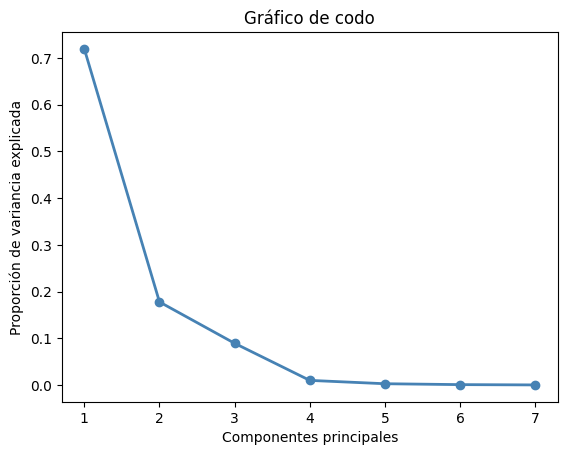

In [90]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='steelblue')
plt.title('Gráfico de codo')
plt.xlabel('Componentes principales')
plt.ylabel('Proporción de variancia explicada')
plt.show()

Al observar el gráfico del codo, vemos que el quiebre parece producirse entre la segunda y tercera componente. Considerando la primera y la segunda componentes llegaríamos a un ~60% de la variabilidad total, por lo que consideramos óptimo tomar hasta la tercera componente.

### Matriz de correlación de componentes principales seleccionados

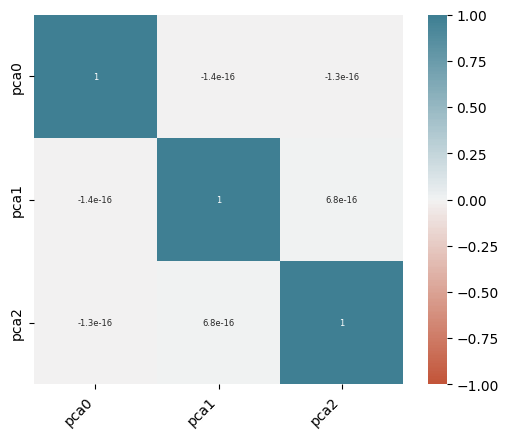

In [91]:
corr = pca_df[['pca0', 'pca1', 'pca2']].corr()
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot = True,
    annot_kws = {'size': 6}
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
)
plt.show()

Gráfico de dispersión

In [92]:
import matplotlib.colors as mcolors

features = df.drop(columns=['category']).columns.to_list()

unique_target = df['category'].unique()
num_colors = len(unique_target)
color_palette = plt.get_cmap('tab20', num_colors)
target_color_map = {cultivo: mcolors.to_hex(color_palette(i)) for i,
                       cultivo in enumerate(unique_target)}

loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
fig = px.scatter(pca_df, x='pca0', y='pca1', color = pca_df["target"],
                 labels={'color': 'target'},
                 color_discrete_map=target_color_map,
                 title="Distribución de las variedades en 2 dimensiones")

fig.show()
fig = px.scatter_3d(pca_df, x='pca0', y='pca1', z='pca2',
              color=pca_df["target"],  labels={'color': 'target'},
              color_discrete_map=target_color_map,
              title="Distribución de las variedades en 3 dimensiones")
fig.show()

In [93]:
fig_2d_orig = px.scatter(df, x='area', y='perimeter', color='category',
                         labels={'color': 'Variedad'},
                         title="Distribución de variedades de trigo en 2D (datos originales)")
fig_2d_orig.show()

fig_3d_orig = px.scatter_3d(df, x='area', y='perimeter', z='compactness', color='category',
                            labels={'color': 'Variedad'},
                            title="Distribución de variedades de trigo en 3D (datos originales)")
fig_3d_orig.update_traces(marker_size=5)
fig_3d_orig.show()